# GN Model Validation — Paper Reproducibility & Carena 2012 Fig. 5

Validate the user's GN engine against the two supplied GN-model papers, reproduce Carena et al. (JLT 2012) Fig. 5, and compare a representative subset with `EGN_model/EGN_adaptive.py`.

Paper curve/marker values are digitized from the supplied PDF and therefore carry digitization uncertainty.

In [1]:
from pathlib import Path
import json, os, subprocess, sys
import pandas as pd
from IPython.display import SVG, display
cwd=Path.cwd().resolve()
ROOT=next((p for p in [cwd,*cwd.parents] if (p/'2026_KICS_Fall_10').exists()),None)
if ROOT is None and Path('/content').exists():
    os.chdir('/content')
    if not Path('LSCNS').exists(): subprocess.run(['git','clone','https://github.com/kimheeseo/LSCNS.git'],check=True)
    ROOT=Path('/content/LSCNS')
if ROOT is None: raise RuntimeError('Could not locate LSCNS repository root')
GN_DIR=ROOT/'2026_KICS_Fall_10'/'GN_model'
RES=GN_DIR/'results'
print('Repository:',ROOT)
print('Results:',RES)


Repository: /home/runner/work/LSCNS/LSCNS
Results: /home/runner/work/LSCNS/LSCNS/2026_KICS_Fall_10/GN_model/results


## 1. Paper 1 — equation-level reproducibility

In [2]:
p1=json.loads((RES/'paper1_reproducibility.json').read_text())
display(pd.DataFrame(p1['equation_level_tests']))
display(pd.DataFrame(p1['qmc_convergence']))
print('Assessment:',p1['assessment'])
print('Max equation error [%]:',p1['max_equation_error_pct'])


,test,expected,actual,relative_error
0,dB/km -> field alpha,0.025328,0.025328,0.000000e+00
1,beta2 phase mismatch,2.321787,2.321787,0.000000e+00
2,single-span link function,0.308544,0.308544,5.397403e-16
3,identical-span incoherent accumulation,2.159806,2.159806,4.112307e-16
4,identical-span coherent accumulation,15.070794,15.070794,5.068303e-15
5,non-identical-span coherent phase history,3.463458,3.463458,1.153992e-15
6,common launch-power cubic scaling,8.000000,8.000000,1.294520e-13


,sobol_power,samples,mean_W_per_THz,relative_std_pct,relative_change_vs_previous_pct
0,11,2048,0.000004,2.252013,NaN
1,13,8192,0.000004,0.222265,2.296145
2,15,32768,0.000004,0.093489,0.144091


Assessment: PASS
Max equation error [%]: 1.2945200467129325e-11


## 2. Carena 2012 Figure 5 — paper vs GN code

In [3]:
g=pd.read_csv(RES/'figure5_reproduction.csv')
display(g[['fiber','modulation','spacing_GHz','net_SE_bit_s_Hz','paper_Lmax_km','gn_Lmax_km','gn_error_pct']])
print('GN MAPE [%]:',g.gn_error_pct.mean())
print('GN median APE [%]:',g.gn_error_pct.median())
print('GN max APE [%]:',g.gn_error_pct.max())


,fiber,modulation,spacing_GHz,net_SE_bit_s_Hz,paper_Lmax_km,gn_Lmax_km,gn_error_pct
0,PSCF,BPSK,50.0,1.0000,17300,20600.0,19.075145
1,PSCF,BPSK,38.4,1.3021,15300,17300.0,13.071895
2,PSCF,BPSK,35.2,1.4205,14100,15500.0,9.929078
3,PSCF,BPSK,33.6,1.4881,12700,13800.0,8.661417
4,PSCF,BPSK,32.8,1.5244,11500,12600.0,9.565217
...,...,...,...,...,...,...,...
58,NZDSF,8QAM,32.8,4.5732,300,200.0,33.333333
59,NZDSF,16QAM,50.0,4.0000,500,500.0,0.000000
60,NZDSF,16QAM,38.4,5.2083,400,300.0,25.000000
61,NZDSF,16QAM,36.8,5.4348,300,300.0,0.000000


GN MAPE [%]: 8.655676101720614
GN median APE [%]: 6.666666666666667
GN max APE [%]: 50.0


## 3. Paper vs GN vs EGN

Carena-2012 Fig. 5 is a **GN-model** benchmark and its model curves use incoherent span accumulation. `EGN_adaptive.py`'s native full path instead uses rectangular spectra and coherent multi-span EGN physics. Therefore the three-way graph uses a transparent **paper-convention proxy** for representative 50-GHz QPSK points on PSCF, SMF and NZDSF: full one-span EGN NLI is calculated by `EGN_adaptive.py`, then accumulated incoherently across spans like Fig. 5. The EGN error is shown for comparison, but it is not treated as a native full-EGN validation score.

,fiber,modulation,spacing_GHz,paper_Lmax_km,gn_Lmax_km,egn_Lmax_km,gn_error_pct,egn_error_pct,egn_to_gn_nli_ratio_db
0,PSCF,QPSK,50.0,8900,10200.0,14900.0,14.606742,67.415730,-5.785066
1,SMF,QPSK,50.0,4100,4400.0,6500.0,7.317073,58.536585,-5.822229
2,NZDSF,QPSK,50.0,2700,2800.0,4000.0,3.703704,48.148148,-5.355844


Same-subset GN MAPE [%]: 8.542506149156372
EGN MAPE [%]: 58.033487950360154


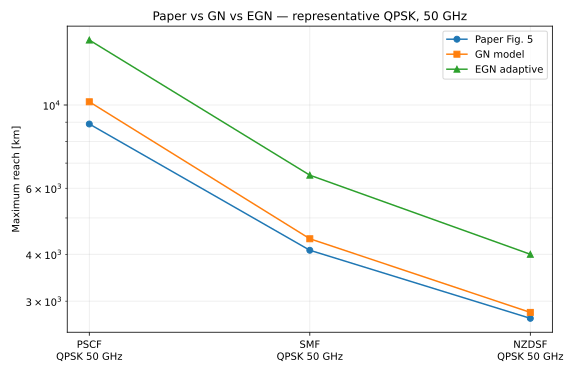

In [4]:
e=pd.read_csv(RES/'paper_gn_egn_comparison.csv')
display(e[['fiber','modulation','spacing_GHz','paper_Lmax_km','gn_Lmax_km','egn_Lmax_km','gn_error_pct','egn_error_pct','egn_to_gn_nli_ratio_db']])
print('Same-subset GN MAPE [%]:',e.gn_error_pct.mean())
print('EGN MAPE [%]:',e.egn_error_pct.mean())
display(SVG(filename=str(RES/'paper_gn_egn_parity.svg')))


## 4. Machine-readable summary and limitations

In [5]:
summary=json.loads((RES/'summary.json').read_text())
print(json.dumps(summary,indent=2))


{
  "figure5_points": 63,
  "gn_mape_pct": 8.655676101720614,
  "gn_median_ape_pct": 6.666666666666667,
  "gn_max_ape_pct": 50.0,
  "egn_subset_points": 3,
  "egn_subset_mape_pct": 58.033487950360154,
  "egn_subset_median_ape_pct": 58.536585365853654,
  "egn_subset_max_ape_pct": 67.41573033707866,
  "gn_same_subset_mape_pct": 8.542506149156372,
  "paper_digitization_uncertainty_pct_range": [
    4.0,
    8.0
  ],
  "important_scope_notes": [
    "Paper Fig.5 GN uses incoherent span accumulation; the GN reproduction matches that convention.",
    "GN Tx PSD uses NRZ sinc^2 multiplied by a fourth-order super-Gaussian with Bopt=spacing, normalized to channel power.",
    "The EGN three-way comparison is a paper-convention proxy: full one-span EGN is calculated by EGN_adaptive, then scaled incoherently across spans like Carena-2012 Fig.5. It is not a native multi-span EGN accuracy benchmark.",
    "No fitted NLI scale factor is used.",
    "Paper Fig.5 and Fig.3 values are digitized from t

## 5. Optional: recompute from scratch in Colab

Set `RUN_HEAVY=True` to rerun the numerical GN and full-EGN calculations.

In [6]:
RUN_HEAVY=False
if RUN_HEAVY:
    subprocess.run([sys.executable,str(GN_DIR/'paper1_reproducibility.py')],cwd=ROOT,check=True)
    subprocess.run([sys.executable,str(GN_DIR/'figure5_benchmark.py')],cwd=ROOT,check=True)
    print('Recalculation complete.')
else:
    print('Using committed execution results. Set RUN_HEAVY=True to recompute.')


Using committed execution results. Set RUN_HEAVY=True to recompute.
